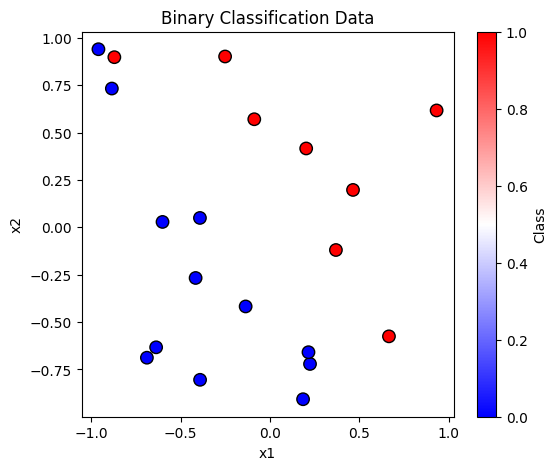

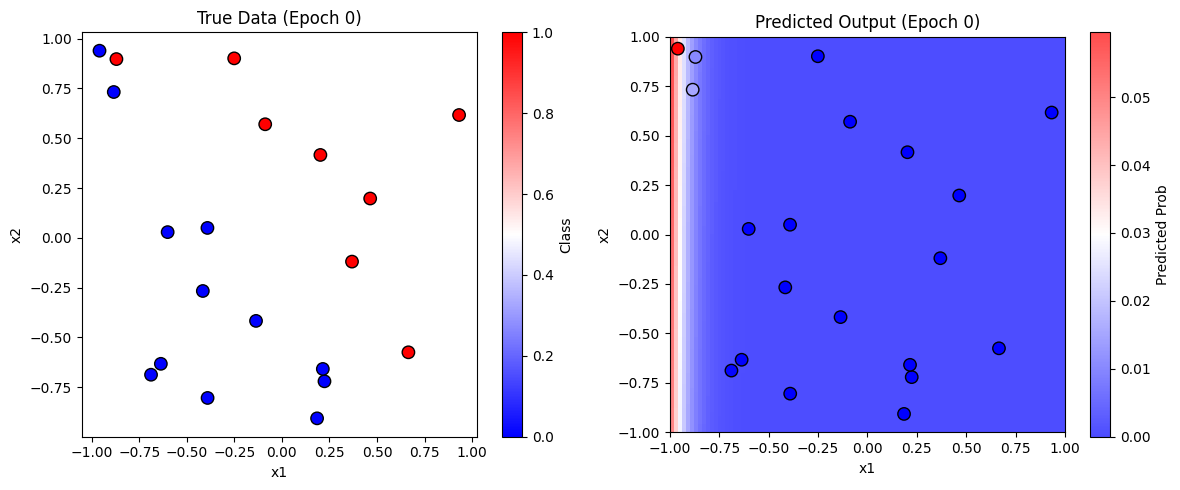

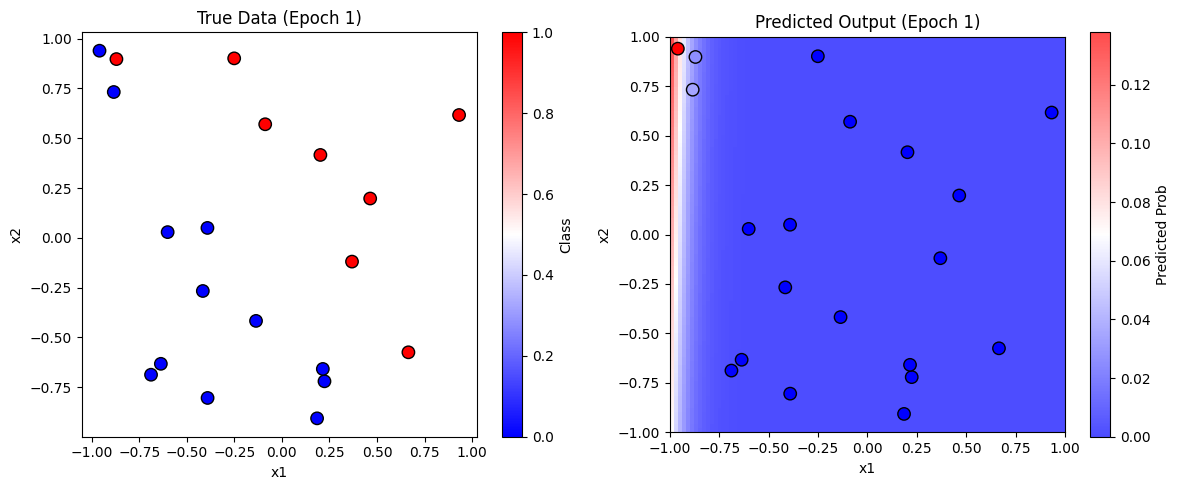

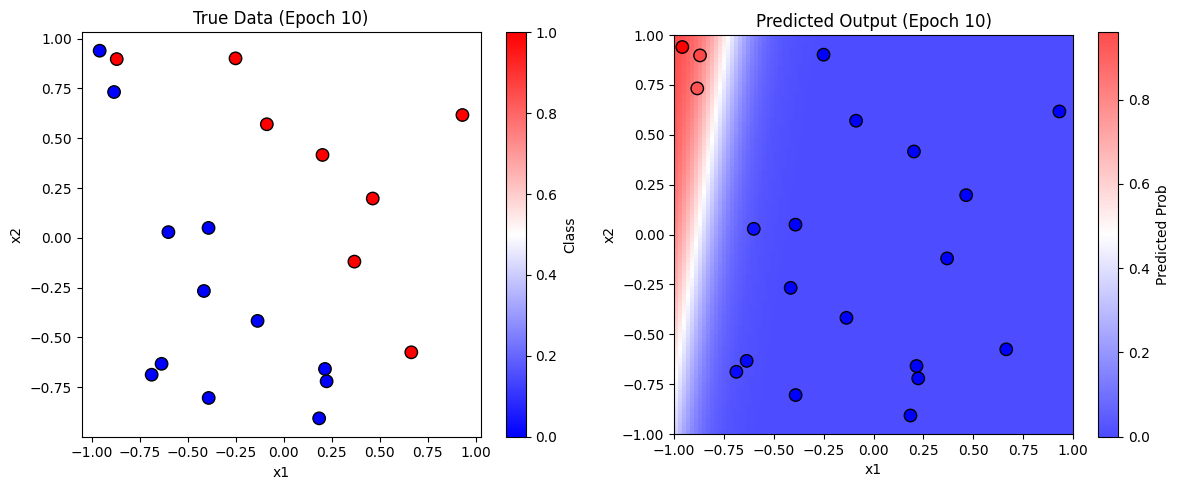

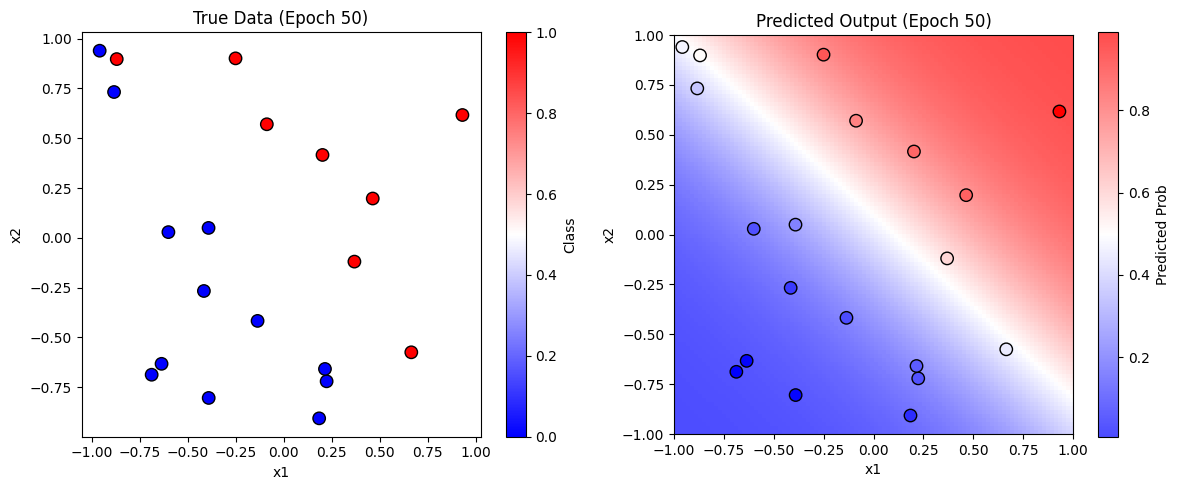

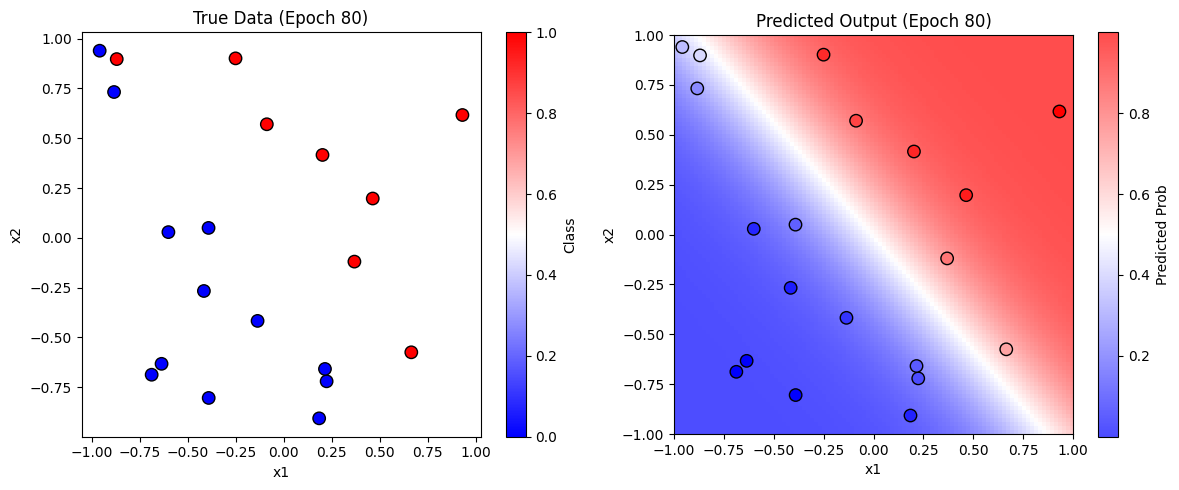

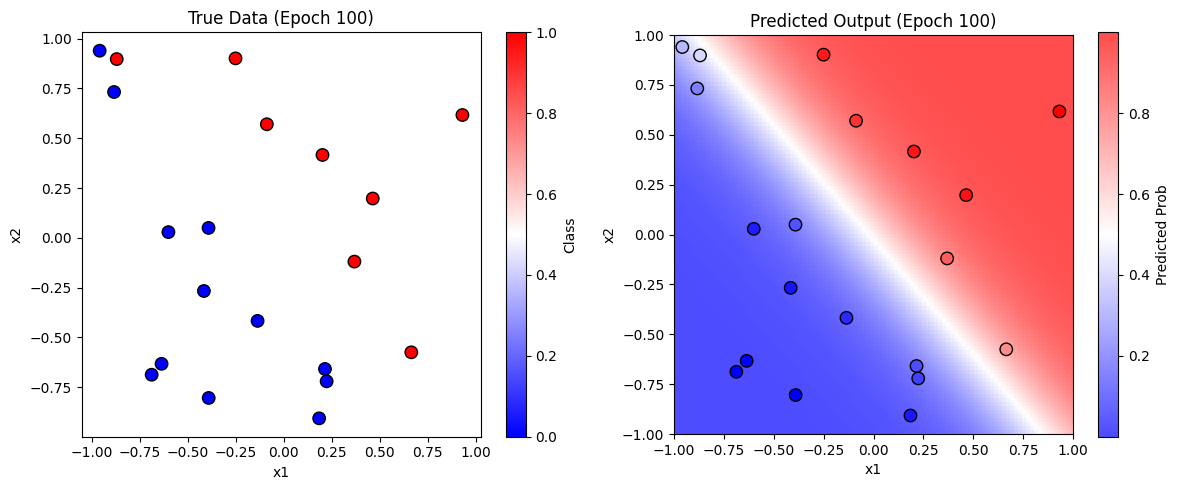

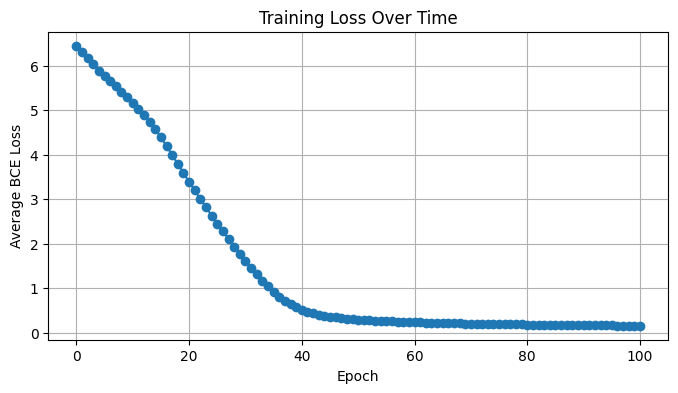

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Sigmoid activation
# -------------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# -------------------------------
# Generate simple 2D classification data
# -------------------------------
np.random.seed(42)
num_samples = 20

X = np.random.uniform(-1, 1, (num_samples, 2))
x1_vals = X[:,0]
x2_vals = X[:,1]

# Target: label 1 if x1 + x2 > 0, else 0
y_true = ((x1_vals + x2_vals) > 0).astype(int).reshape(-1,1)

plt.figure(figsize=(6,5))
plt.scatter(x1_vals, x2_vals, c=y_true.flatten(), cmap='bwr', edgecolor='k', s=80)
plt.colorbar(label="Class")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Binary Classification Data")
plt.show()

# -------------------------------
# Initialize weights and bias (2-1 network)
# -------------------------------
# Start bad initialization
w1, w2, b = np.random.uniform(-20, 20), np.random.uniform(-20, 20), np.random.uniform(-20,20)

learning_rate = 0.1
epochs = 100
loss_history = []
checkpoints = [0, 1, 10, 50, 80, 100]

# -------------------------------
# Training loop (single-layer)
# -------------------------------
for epoch in range(epochs+1):
    total_loss = 0
    for i in range(num_samples):
        x1 = X[i,0]
        x2 = X[i,1]
        y = y_true[i,0]

        # Forward pass
        z = w1*x1 + w2*x2 + b
        a = sigmoid(z)

        # Binary cross-entropy loss
        loss = -(y*np.log(a + 1e-8) + (1-y)*np.log(1-a + 1e-8))
        total_loss += loss

        # Backprop
        dL_da = -(y/a) + ((1-y)/(1-a))
        dL_dz = dL_da * a * (1-a)

        dL_dw1 = dL_dz * x1
        dL_dw2 = dL_dz * x2
        dL_db  = dL_dz

        # Gradient descent update
        w1 -= learning_rate * dL_dw1
        w2 -= learning_rate * dL_dw2
        b  -= learning_rate * dL_db

    loss_history.append(total_loss / num_samples)

    if epoch in checkpoints:
        # Compute predictions for all points
        y_pred = sigmoid(w1*X[:,0] + w2*X[:,1] + b)

        # --- Plot predictions as a surface ---
        xx = np.linspace(-1,1,100)
        yy = np.linspace(-1,1,100)
        XX, YY = np.meshgrid(xx, yy)
        ZZ = sigmoid(w1*XX + w2*YY + b)

        fig, axs = plt.subplots(1,2,figsize=(12,5))

        # 1. True data
        sc0 = axs[0].scatter(X[:,0], X[:,1], c=y_true.flatten(), cmap='bwr', edgecolor='k', s=80)
        axs[0].set_xlabel("x1")
        axs[0].set_ylabel("x2")
        axs[0].set_title(f"True Data (Epoch {epoch})")
        plt.colorbar(sc0, ax=axs[0], label="Class")

        # 2. Predicted data surface
        im = axs[1].imshow(ZZ, extent=[-1,1,-1,1], origin='lower', cmap='bwr', alpha=0.7)
        # Set color based on predicted probability for each point
        sc1 = axs[1].scatter(X[:,0], X[:,1], c=y_pred.flatten(), cmap='bwr', edgecolor='k', s=80)
        axs[1].set_xlabel("x1")
        axs[1].set_ylabel("x2")
        axs[1].set_title(f"Predicted Output (Epoch {epoch})")
        plt.colorbar(im, ax=axs[1], label="Predicted Prob")


        plt.tight_layout()
        plt.show()

# -------------------------------
# Final loss plot
# -------------------------------
plt.figure(figsize=(8,4))
plt.plot(loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average BCE Loss")
plt.title("Training Loss Over Time")
# plt.yscale('log')
plt.grid(True)
plt.show()


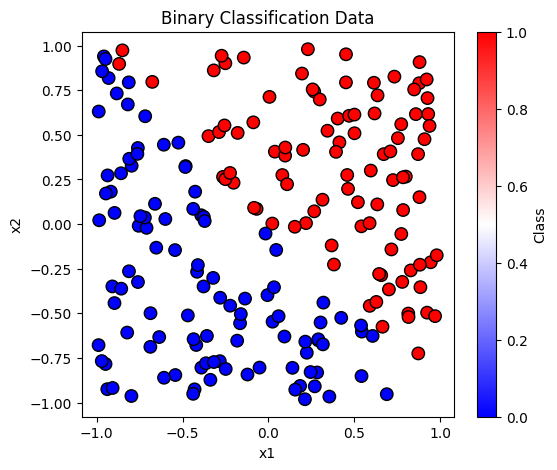

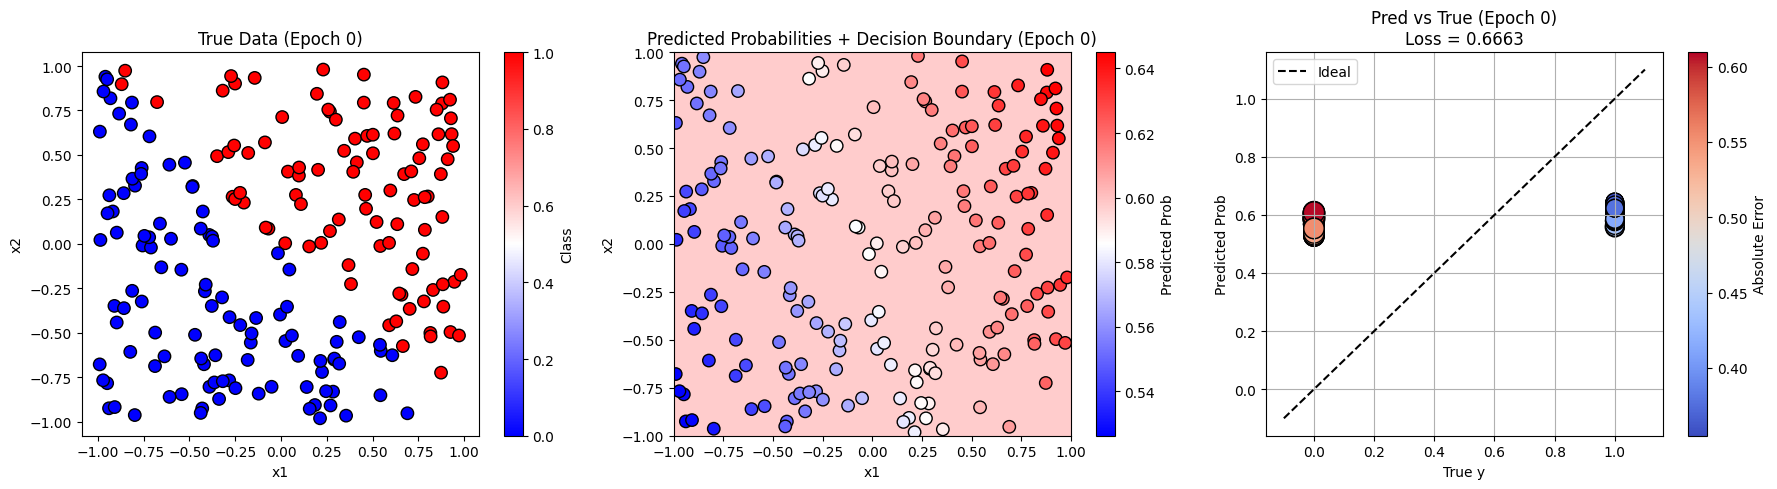

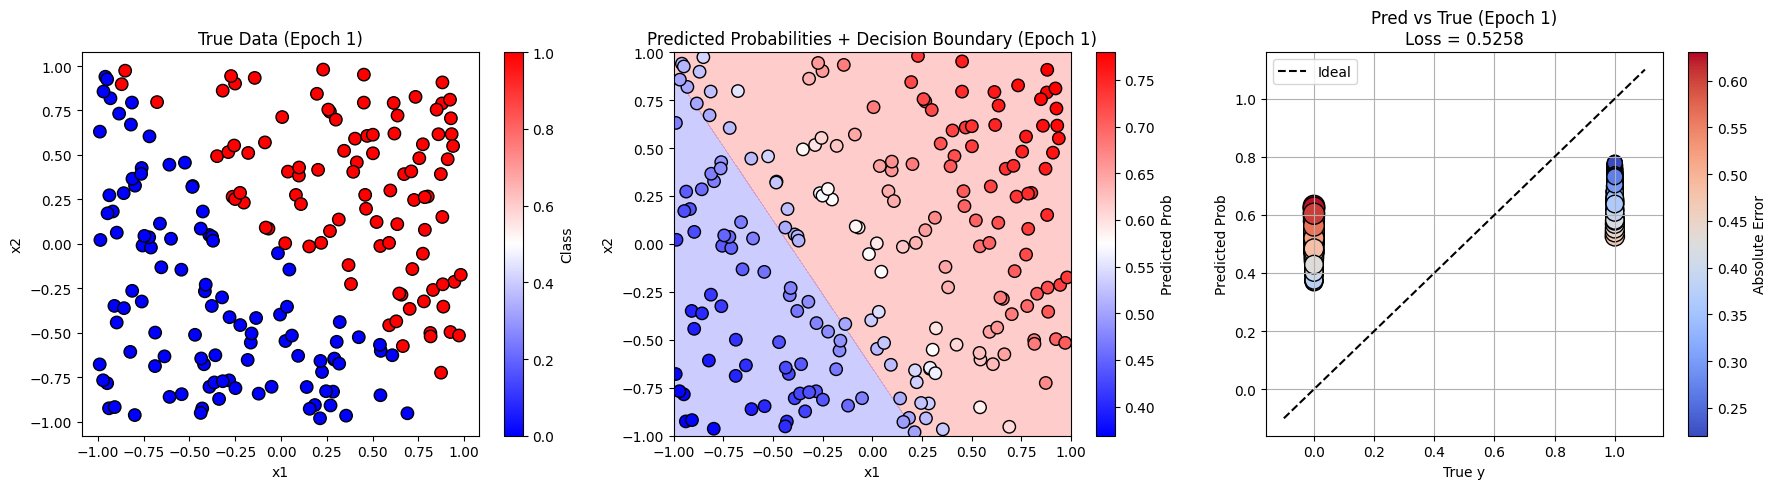

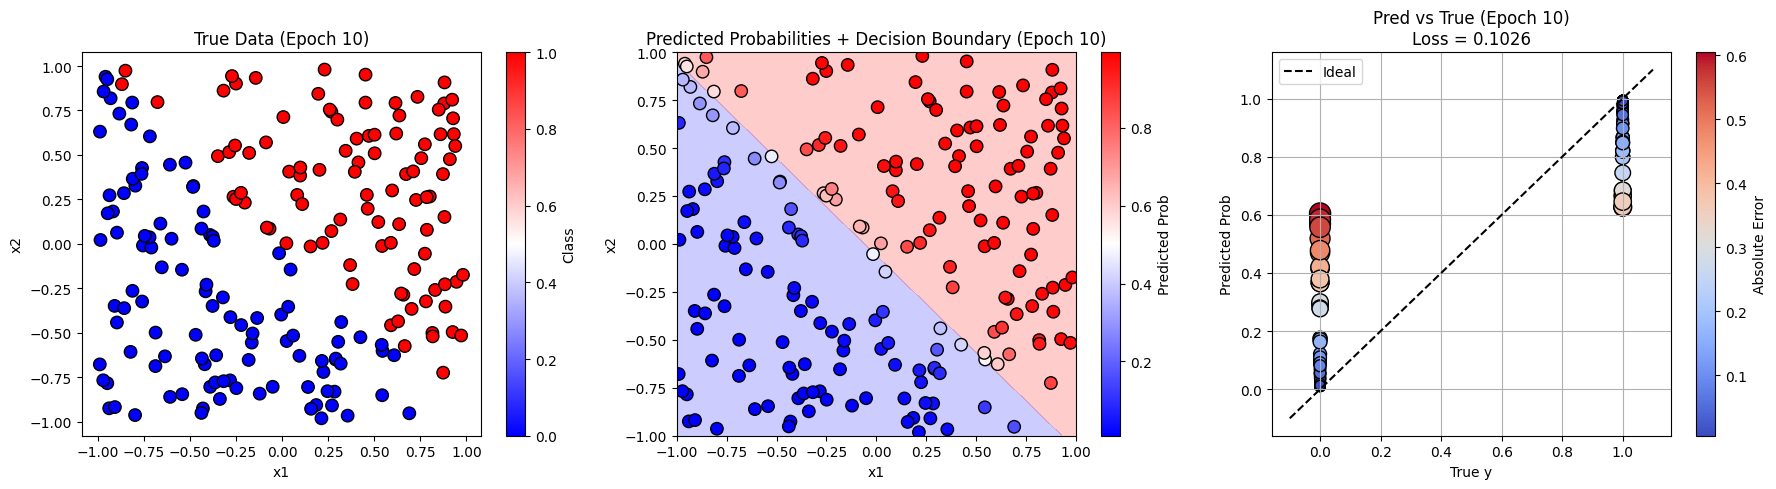

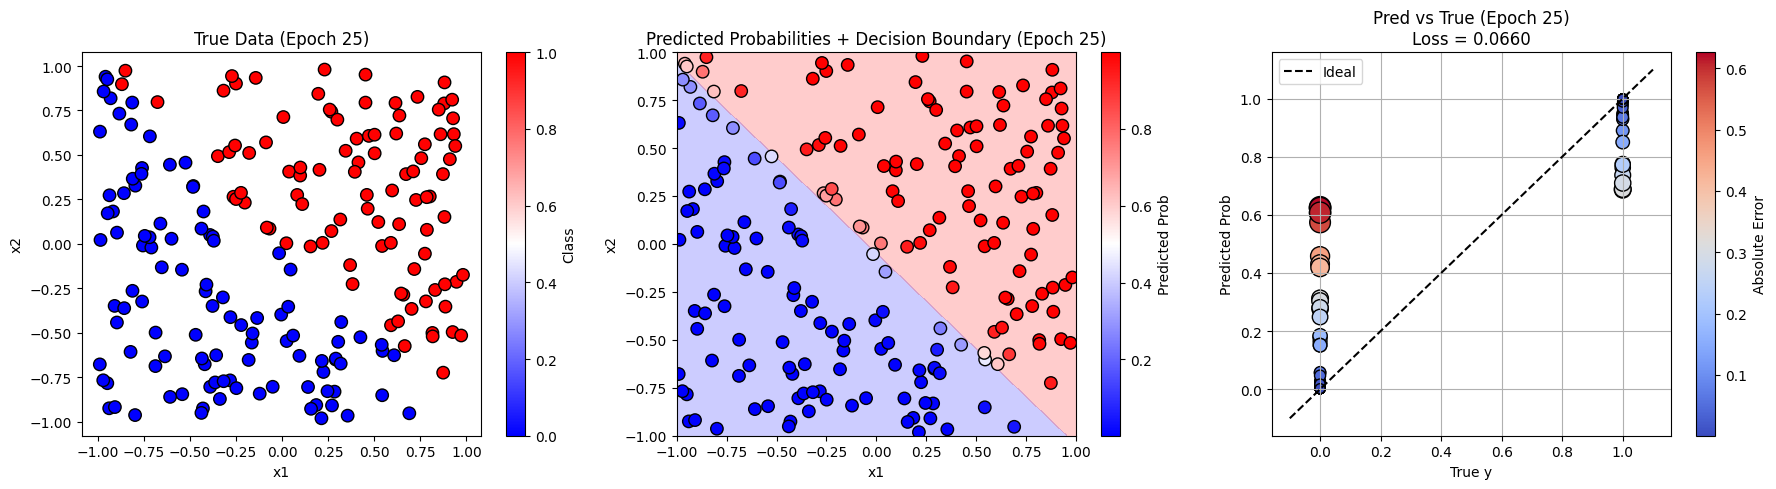

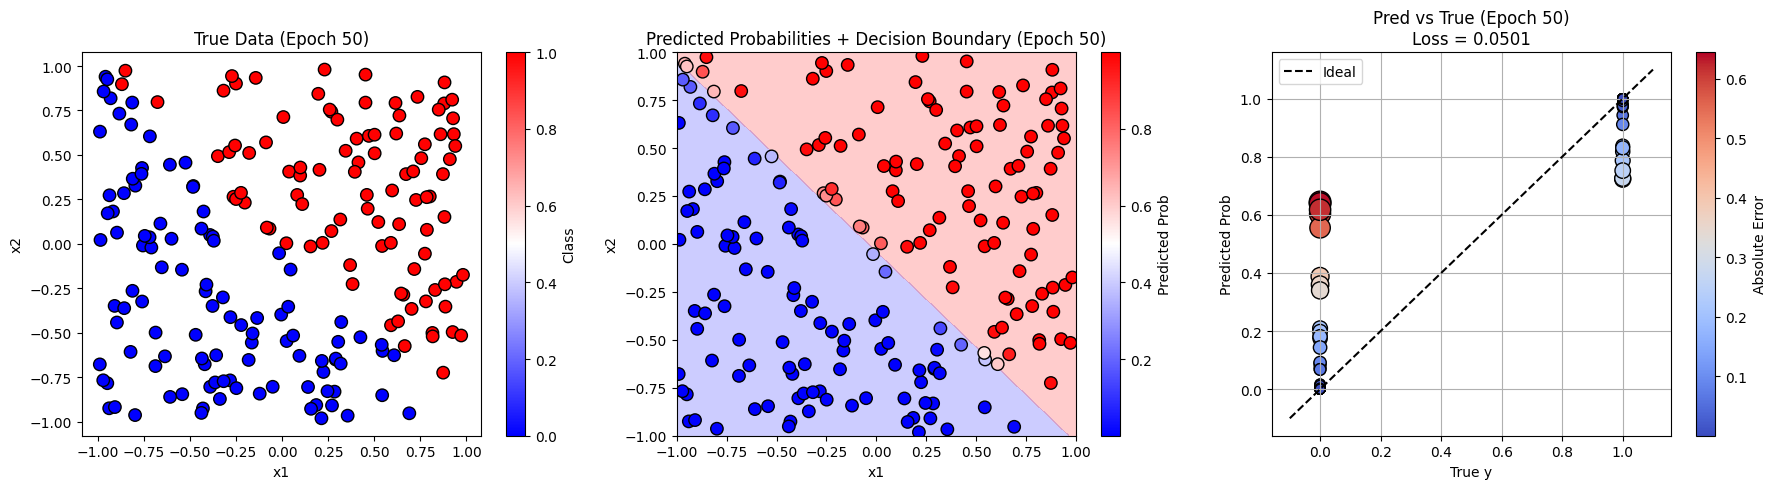

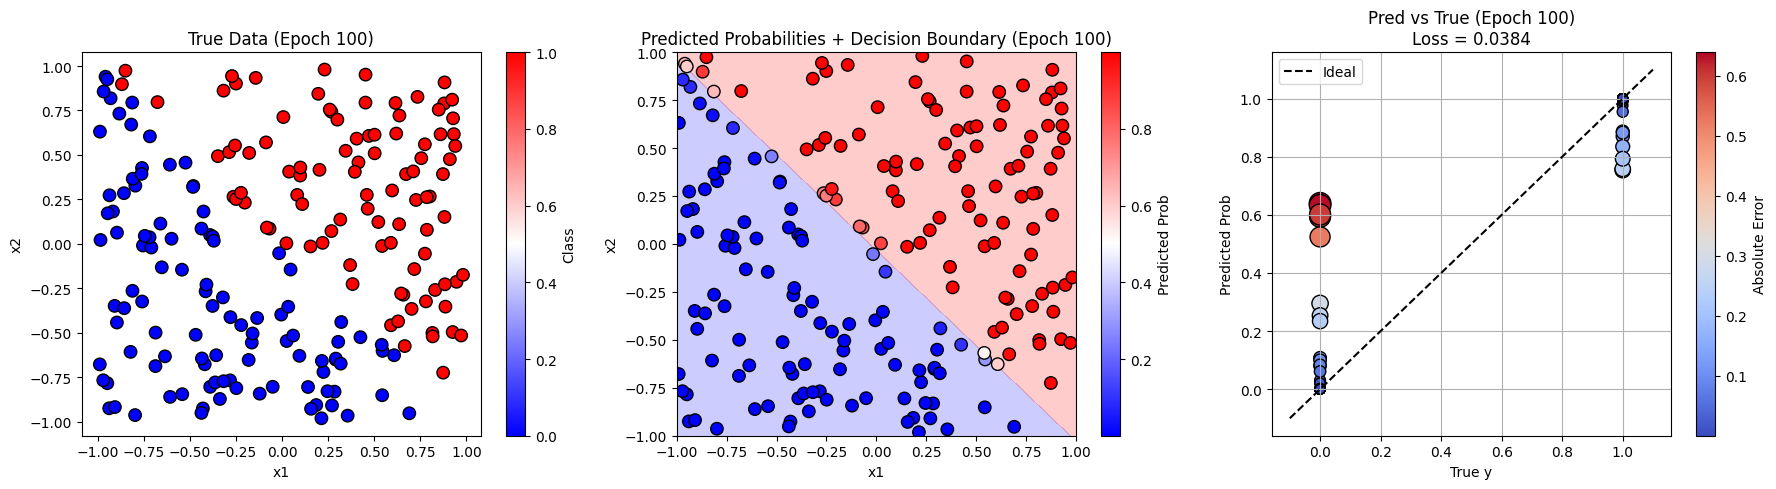

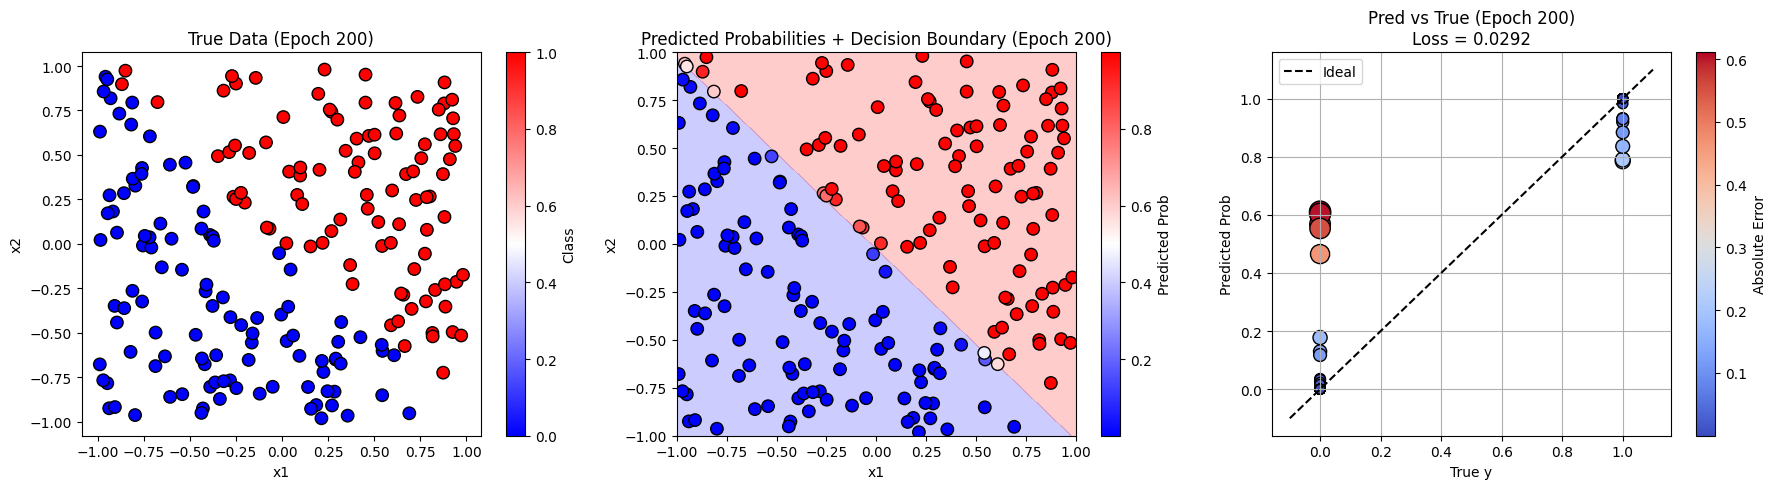

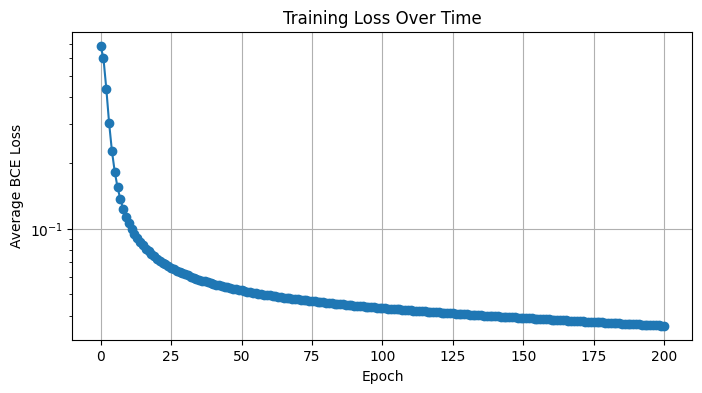

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Sigmoid activation
# -------------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# -------------------------------
# Generate simple 2D classification data
# -------------------------------
np.random.seed(42)
num_samples = 200

X = np.random.uniform(-1, 1, (num_samples, 2))
x1_vals = X[:,0]
x2_vals = X[:,1]

# Target: label 1 if x1 + x2 > 0, else 0
y_true = ((x1_vals + x2_vals) > 0).astype(int).reshape(-1,1)

plt.figure(figsize=(6,5))
plt.scatter(x1_vals, x2_vals, c=y_true.flatten(), cmap='bwr', edgecolor='k', s=80)
plt.colorbar(label="Class")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Binary Classification Data")
plt.show()

# -------------------------------
# Initialize weights and biases (2-2-1 network)
# -------------------------------
w_1_1, w_1_2, b_1 = np.random.randn()*0.5, np.random.randn()*0.5, 0.0
w_2_1, w_2_2, b_2 = np.random.randn()*0.5, np.random.randn()*0.5, 0.0
w_3_1, w_3_2, b_3 = np.random.randn()*0.5, np.random.randn()*0.5, 0.0

learning_rate = 0.1
epochs = 200
loss_history = []

checkpoints = [0, 1, 10, 25, 50, 100, 200]

# -------------------------------
# Training loop
# -------------------------------
for epoch in range(epochs+1):
    total_loss = 0
    for i in range(num_samples):
        x1 = X[i,0]
        x2 = X[i,1]
        y = y_true[i,0]

        # Forward pass
        z1 = w_1_1*x1 + w_1_2*x2 + b_1
        a1 = sigmoid(z1)
        z2 = w_2_1*x1 + w_2_2*x2 + b_2
        a2 = sigmoid(z2)
        z3 = w_3_1*a1 + w_3_2*a2 + b_3
        a3 = sigmoid(z3)

        # Binary cross-entropy
        loss = -(y*np.log(a3 + 1e-8) + (1-y)*np.log(1-a3 + 1e-8))
        total_loss += loss

        # Backprop
        dL_da3 = -(y/a3) + ((1-y)/(1-a3))
        dL_dz3 = dL_da3 * a3*(1-a3)

        dL_dw_3_1 = dL_dz3 * a1
        dL_dw_3_2 = dL_dz3 * a2
        dL_db_3   = dL_dz3

        dL_da1 = dL_dz3 * w_3_1
        dL_da2 = dL_dz3 * w_3_2

        dL_dz1 = dL_da1 * sigmoid_derivative(z1)
        dL_dz2 = dL_da2 * sigmoid_derivative(z2)

        dL_dw_1_1 = dL_dz1 * x1
        dL_dw_1_2 = dL_dz1 * x2
        dL_db_1   = dL_dz1

        dL_dw_2_1 = dL_dz2 * x1
        dL_dw_2_2 = dL_dz2 * x2
        dL_db_2   = dL_dz2

        # Update
        w_1_1 -= learning_rate * dL_dw_1_1
        w_1_2 -= learning_rate * dL_dw_1_2
        b_1   -= learning_rate * dL_db_1
        w_2_1 -= learning_rate * dL_dw_2_1
        w_2_2 -= learning_rate * dL_dw_2_2
        b_2   -= learning_rate * dL_db_2
        w_3_1 -= learning_rate * dL_dw_3_1
        w_3_2 -= learning_rate * dL_dw_3_2
        b_3   -= learning_rate * dL_db_3

    loss_history.append(total_loss / num_samples)

    if epoch in checkpoints:
        y_pred = []
        for j in range(num_samples):
            x1 = X[j,0]
            x2 = X[j,1]
            a1 = sigmoid(w_1_1*x1 + w_1_2*x2 + b_1)
            a2 = sigmoid(w_2_1*x1 + w_2_2*x2 + b_2)
            a3 = sigmoid(w_3_1*a1 + w_3_2*a2 + b_3)
            y_pred.append(a3)
        y_pred = np.array(y_pred).flatten()

        # --- Subplots ---
        fig, axs = plt.subplots(1, 3, figsize=(18,5))

        # 1. True data
        sc0 = axs[0].scatter(x1_vals, x2_vals, c=y_true.flatten(), cmap='bwr', edgecolor='k', s=80)
        axs[0].set_xlabel("x1"); axs[0].set_ylabel("x2")
        axs[0].set_title(f"True Data (Epoch {epoch})")
        plt.colorbar(sc0, ax=axs[0], label="Class")

        # 2. Predicted data with decision boundary
        # Create mesh grid
        xx, yy = np.meshgrid(np.linspace(-1,1,200), np.linspace(-1,1,200))
        grid = np.c_[xx.ravel(), yy.ravel()]
        preds_grid = []
        for point in grid:
            x1g, x2g = point
            a1g = sigmoid(w_1_1*x1g + w_1_2*x2g + b_1)
            a2g = sigmoid(w_2_1*x1g + w_2_2*x2g + b_2)
            a3g = sigmoid(w_3_1*a1g + w_3_2*a2g + b_3)
            preds_grid.append(a3g)
        preds_grid = np.array(preds_grid).reshape(xx.shape)
        # contourf for decision regions
        axs[1].contourf(xx, yy, preds_grid, levels=[0,0.5,1], colors=['blue','red'], alpha=0.2)
        sc1 = axs[1].scatter(x1_vals, x2_vals, c=y_pred, cmap='bwr', edgecolor='k', s=80)
        axs[1].set_xlabel("x1"); axs[1].set_ylabel("x2")
        axs[1].set_title(f"Predicted Probabilities + Decision Boundary (Epoch {epoch})")
        plt.colorbar(sc1, ax=axs[1], label="Predicted Prob")

        # 3. Creative Predicted vs True y
        errors = np.abs(y_pred - y_true.flatten())
        colors = errors
        sizes = 50 + errors*300
        sc2 = axs[2].scatter(y_true, y_pred, c=colors, s=sizes, cmap='coolwarm', edgecolor='k')
        axs[2].plot([-0.1,1.1], [-0.1,1.1], 'k--', label='Ideal')
        axs[2].set_xlabel("True y"); axs[2].set_ylabel("Predicted Prob")
        checkpoint_loss = np.mean(-(y_true.flatten()*np.log(y_pred+1e-8) + (1-y_true.flatten())*np.log(1-y_pred+1e-8)))
        axs[2].set_title(f"Pred vs True (Epoch {epoch})\nLoss = {checkpoint_loss:.4f}")
        axs[2].legend(); axs[2].grid(True)
        plt.colorbar(sc2, ax=axs[2], label="Absolute Error")

        plt.tight_layout()
        plt.show()

# -------------------------------
# Final loss plot
# -------------------------------
plt.figure(figsize=(8,4))
plt.plot(loss_history, marker='o')
plt.xlabel("Epoch"); plt.ylabel("Average BCE Loss")
plt.title("Training Loss Over Time")
plt.yscale('log')
plt.grid(True)
plt.show()


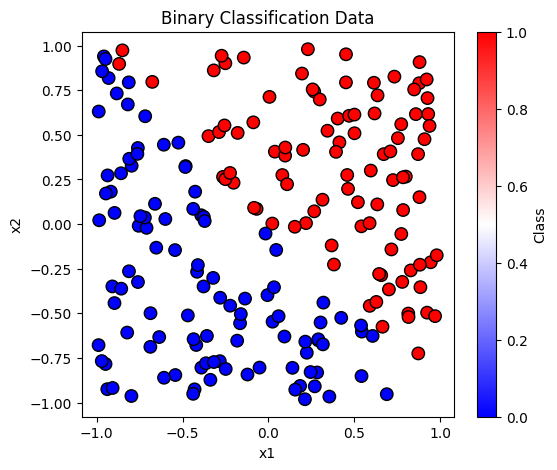

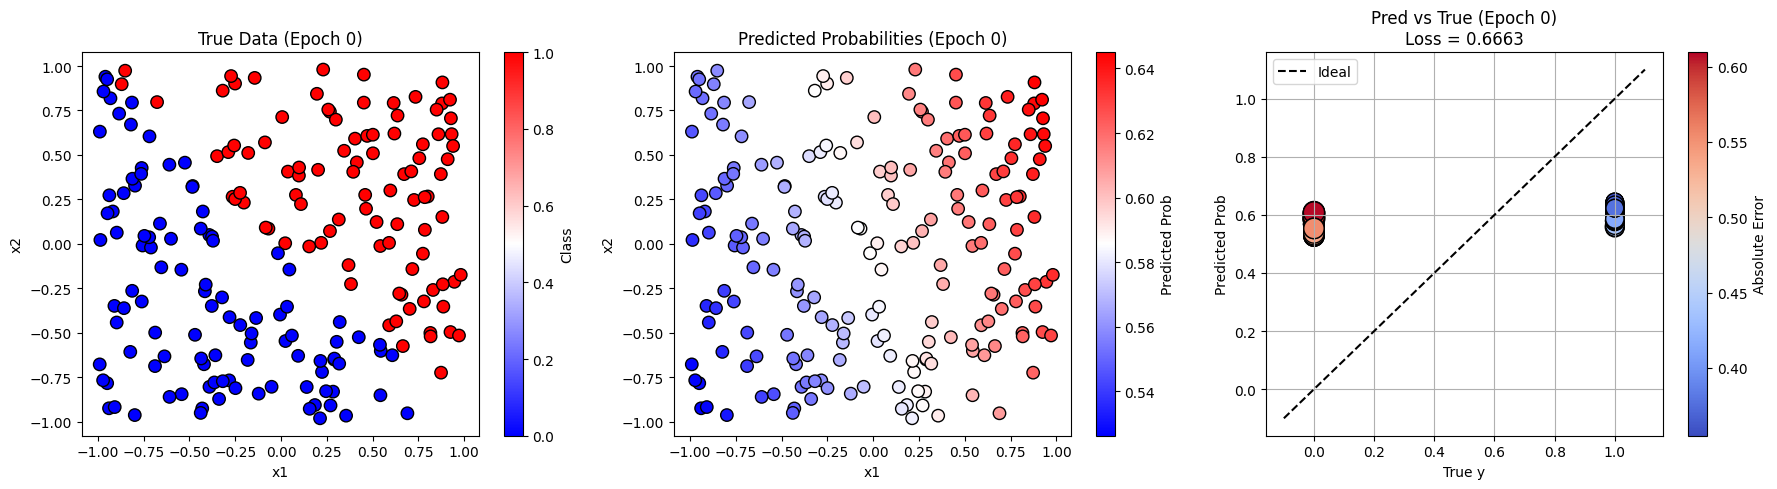

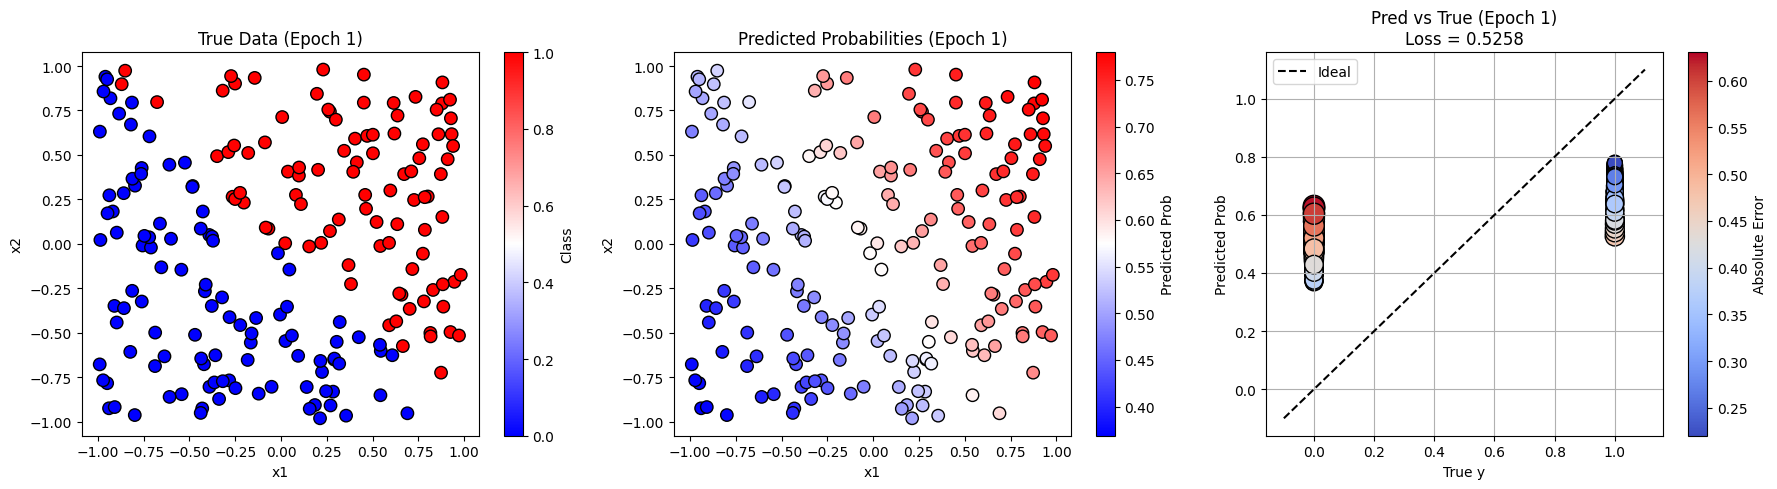

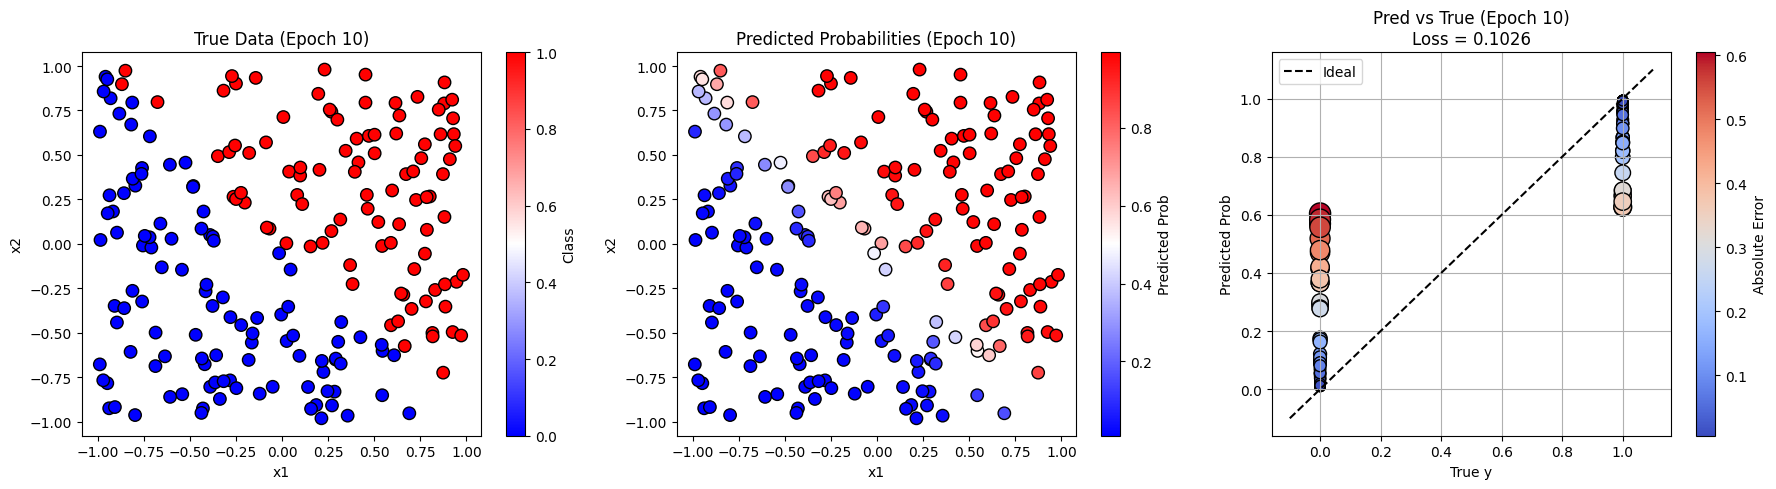

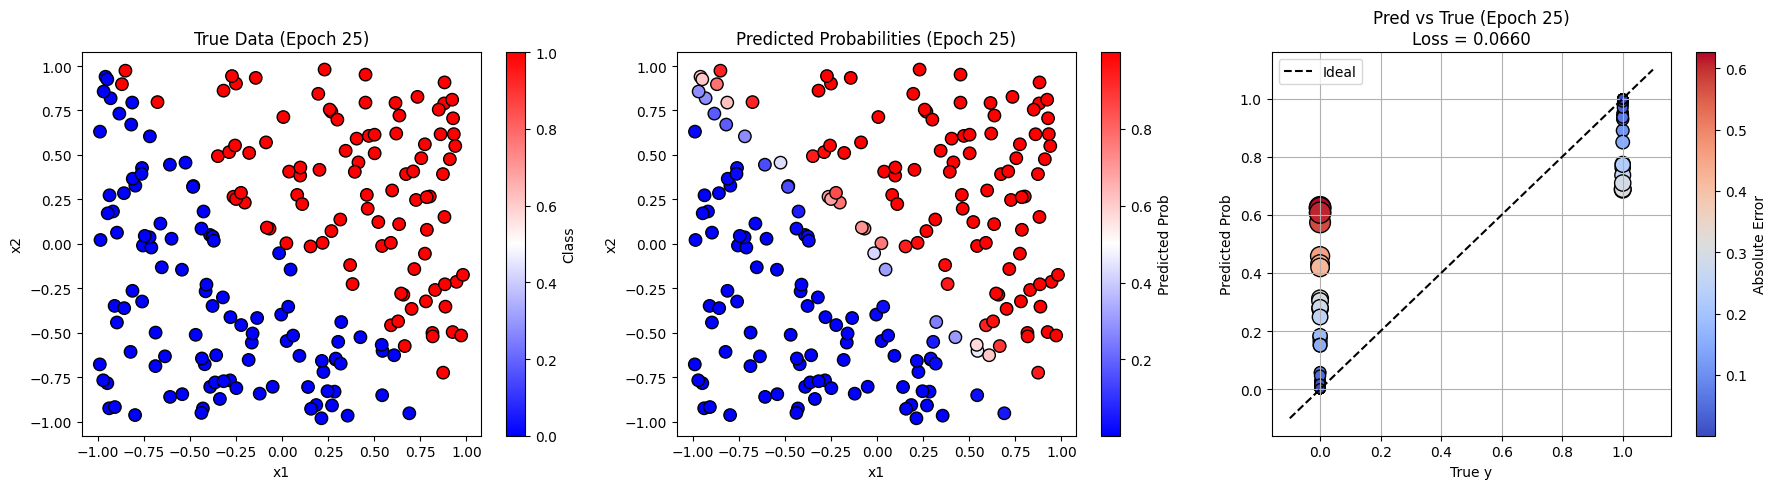

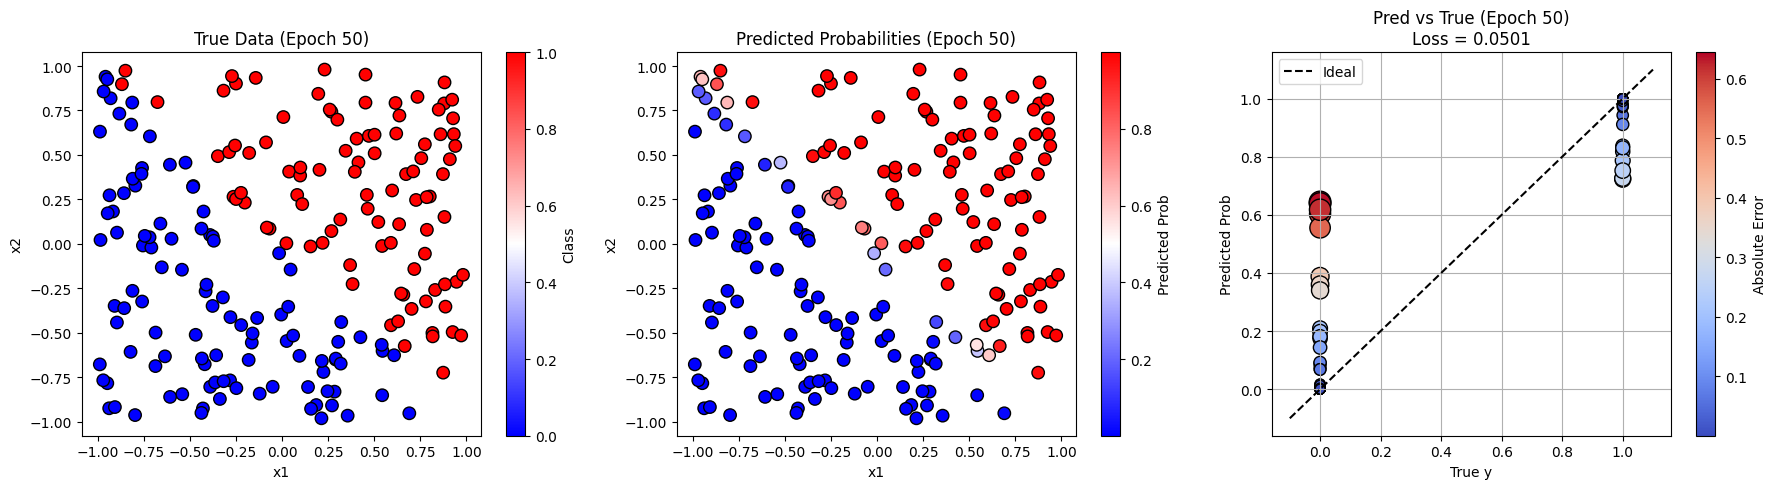

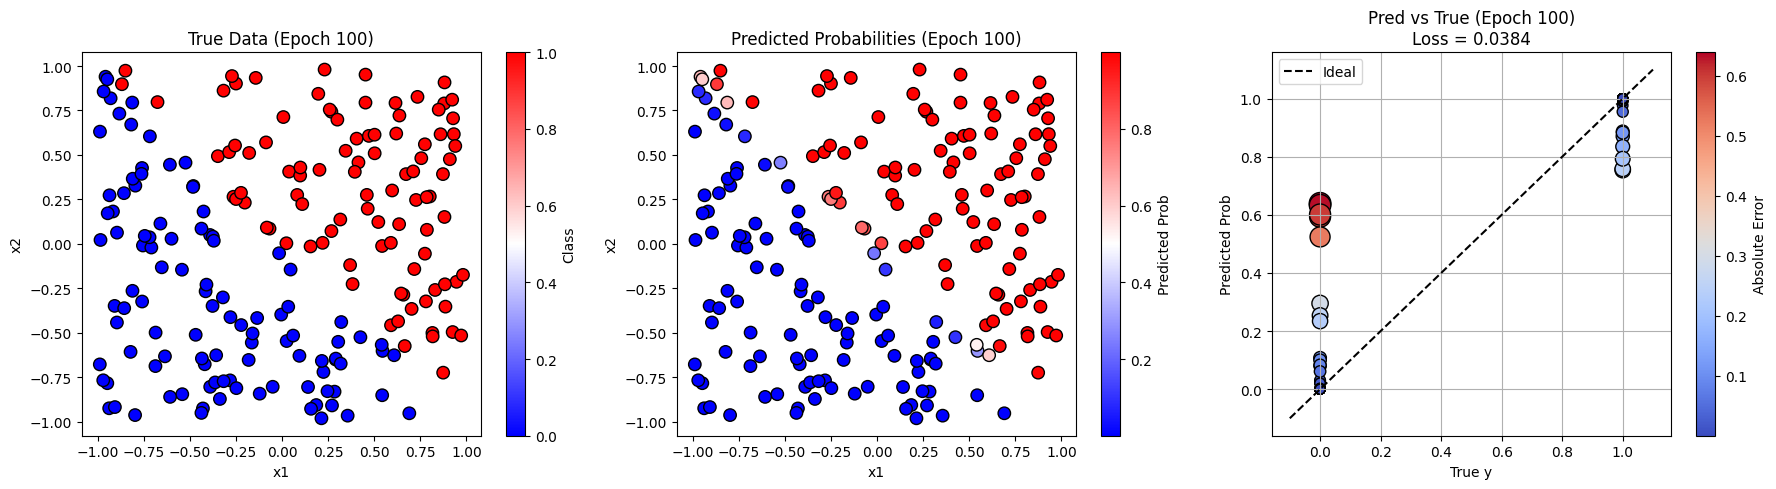

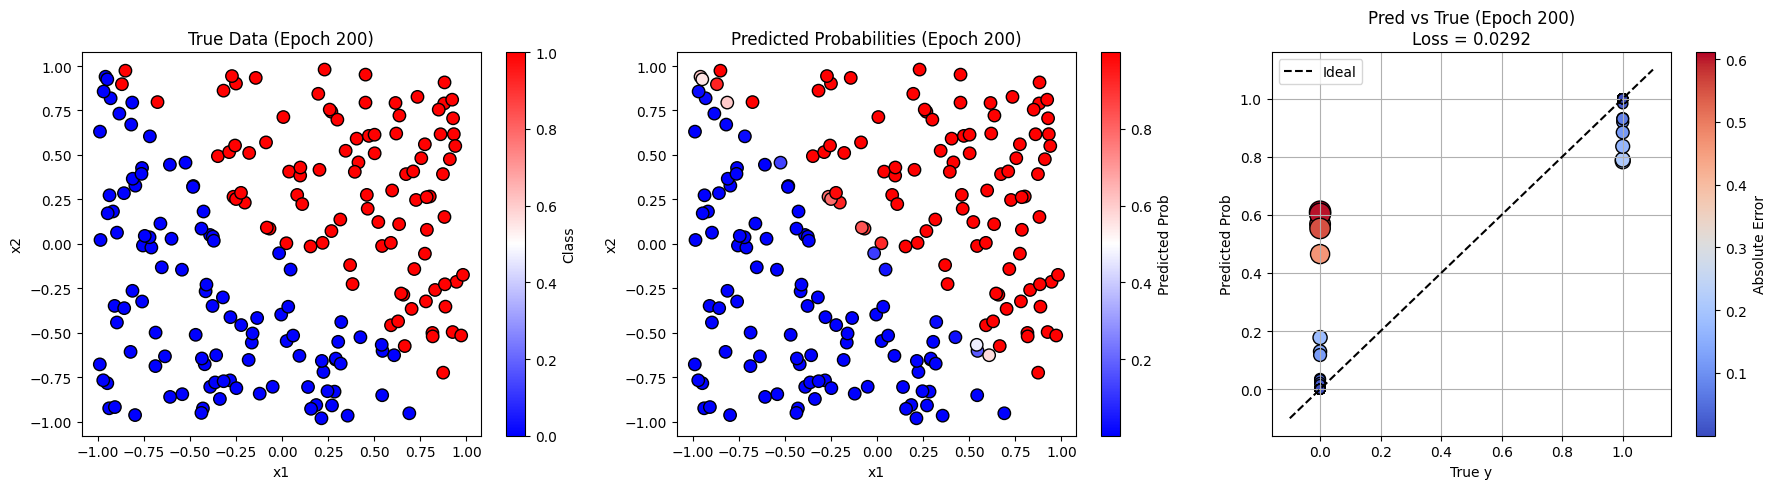

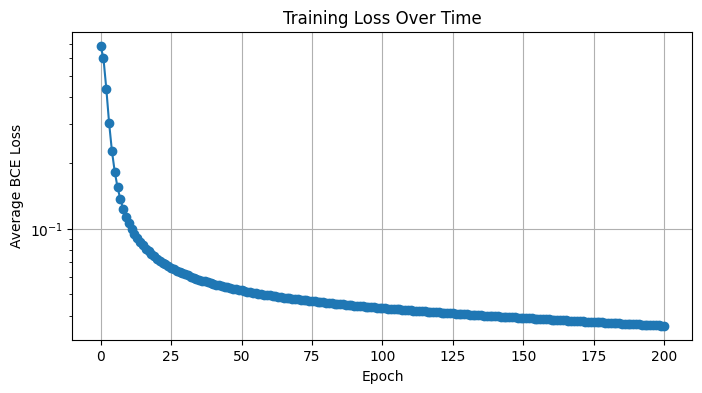

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Sigmoid activation
# -------------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# -------------------------------
# Generate simple 2D classification data
# -------------------------------
np.random.seed(42)
num_samples = 200

# Random points in [-1,1] x [-1,1]
X = np.random.uniform(-1, 1, (num_samples, 2))
x1_vals = X[:,0]
x2_vals = X[:,1]

# Target: label 1 if x1 + x2 > 0, else 0
y_true = ((x1_vals + x2_vals) > 0).astype(int).reshape(-1,1)

# Plot the dataset
plt.figure(figsize=(6,5))
plt.scatter(x1_vals, x2_vals, c=y_true.flatten(), cmap='bwr', edgecolor='k', s=80)
plt.colorbar(label="Class")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Binary Classification Data")
plt.show()

# -------------------------------
# Initialize weights and biases (2-2-1 network)
# -------------------------------
w_1_1, w_1_2, b_1 = np.random.randn()*0.5, np.random.randn()*0.5, 0.0
w_2_1, w_2_2, b_2 = np.random.randn()*0.5, np.random.randn()*0.5, 0.0
w_3_1, w_3_2, b_3 = np.random.randn()*0.5, np.random.randn()*0.5, 0.0

learning_rate = 0.1
epochs = 200
loss_history = []

# Checkpoints to plot predictions
checkpoints = [0, 1, 10, 25, 50, 100, 200]

# -------------------------------
# Training loop (Binary Cross-Entropy)
# -------------------------------
for epoch in range(epochs+1):
    total_loss = 0
    for i in range(num_samples):
        x1 = X[i,0]
        x2 = X[i,1]
        y = y_true[i,0]
        
        # --- Forward pass ---
        z1 = w_1_1*x1 + w_1_2*x2 + b_1
        a1 = sigmoid(z1)
        
        z2 = w_2_1*x1 + w_2_2*x2 + b_2
        a2 = sigmoid(z2)
        
        z3 = w_3_1*a1 + w_3_2*a2 + b_3
        a3 = sigmoid(z3)  # sigmoid for probability
        
        # Binary cross-entropy loss
        loss = -(y*np.log(a3 + 1e-8) + (1-y)*np.log(1 - a3 + 1e-8))
        total_loss += loss
        
        # --- Backpropagation ---
        dL_da3 = -(y/a3) + ((1-y)/(1-a3))  # derivative of BCE w.r.t a3
        dL_dz3 = dL_da3 * a3*(1-a3)  # derivative through sigmoid
        
        # Output neuron gradients
        dL_dw_3_1 = dL_dz3 * a1
        dL_dw_3_2 = dL_dz3 * a2
        dL_db_3   = dL_dz3
        
        # Hidden layer gradients
        dL_da1 = dL_dz3 * w_3_1
        dL_da2 = dL_dz3 * w_3_2
        
        dL_dz1 = dL_da1 * sigmoid_derivative(z1)
        dL_dz2 = dL_da2 * sigmoid_derivative(z2)
        
        dL_dw_1_1 = dL_dz1 * x1
        dL_dw_1_2 = dL_dz1 * x2
        dL_db_1   = dL_dz1
        
        dL_dw_2_1 = dL_dz2 * x1
        dL_dw_2_2 = dL_dz2 * x2
        dL_db_2   = dL_dz2
        
        # Gradient descent update
        w_1_1 -= learning_rate * dL_dw_1_1
        w_1_2 -= learning_rate * dL_dw_1_2
        b_1   -= learning_rate * dL_db_1
        
        w_2_1 -= learning_rate * dL_dw_2_1
        w_2_2 -= learning_rate * dL_dw_2_2
        b_2   -= learning_rate * dL_db_2
        
        w_3_1 -= learning_rate * dL_dw_3_1
        w_3_2 -= learning_rate * dL_dw_3_2
        b_3   -= learning_rate * dL_db_3
    
    loss_history.append(total_loss / num_samples)
    
    # -------------------------------
    # Plot predictions at checkpoints
    # -------------------------------
    if epoch in checkpoints:
        y_pred = []
        for j in range(num_samples):
            x1 = X[j,0]
            x2 = X[j,1]
            a1 = sigmoid(w_1_1*x1 + w_1_2*x2 + b_1)
            a2 = sigmoid(w_2_1*x1 + w_2_2*x2 + b_2)
            a3 = sigmoid(w_3_1*a1 + w_3_2*a2 + b_3)
            y_pred.append(a3)
        y_pred = np.array(y_pred).flatten()
        
        # --- Horizontal subplots ---
        fig, axs = plt.subplots(1, 3, figsize=(18,5))
        
        # 1. True data
        sc0 = axs[0].scatter(x1_vals, x2_vals, c=y_true.flatten(), cmap='bwr', edgecolor='k', s=80)
        axs[0].set_xlabel("x1")
        axs[0].set_ylabel("x2")
        axs[0].set_title(f"True Data (Epoch {epoch})")
        plt.colorbar(sc0, ax=axs[0], label="Class")
        
        # 2. Predicted data
        sc1 = axs[1].scatter(x1_vals, x2_vals, c=y_pred, cmap='bwr', edgecolor='k', s=80)
        axs[1].set_xlabel("x1")
        axs[1].set_ylabel("x2")
        axs[1].set_title(f"Predicted Probabilities (Epoch {epoch})")
        plt.colorbar(sc1, ax=axs[1], label="Predicted Prob")
        
        # 3. Creative Predicted vs True y
        errors = np.abs(y_pred - y_true.flatten())
        colors = errors
        sizes = 50 + errors*300
        
        sc2 = axs[2].scatter(y_true, y_pred, c=colors, s=sizes, cmap='coolwarm', edgecolor='k')
        axs[2].plot([-0.1,1.1], [-0.1,1.1], 'k--', label='Ideal')
        axs[2].set_xlabel("True y")
        axs[2].set_ylabel("Predicted Prob")
        
        # Compute checkpoint loss
        checkpoint_loss = np.mean(-(y_true.flatten()*np.log(y_pred+1e-8) + (1-y_true.flatten())*np.log(1-y_pred+1e-8)))
        axs[2].set_title(f"Pred vs True (Epoch {epoch})\nLoss = {checkpoint_loss:.4f}")
        axs[2].legend()
        axs[2].grid(True)
        plt.colorbar(sc2, ax=axs[2], label="Absolute Error")
        
        plt.tight_layout()
        plt.show()

# -------------------------------
# Final loss plot
# -------------------------------
plt.figure(figsize=(8,4))
plt.plot(loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average BCE Loss")
plt.title("Training Loss Over Time")
plt.yscale('log')
plt.grid(True)
plt.show()
